# 1\. 데이터 개요 및 환경 설정

## 1\) 라이브러리 임포트 및 데이터 로드

In [5]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('./heart_failure_clinical_records_dataset.csv')

**데이터셋 구성**

|변수명|설명|
|:---:|---|
|age|환자의 나이|
|anaemia|빈혈 여부 (0: 정상, 1: 빈혈)|
|creatinine_phosphokinase|크레아틴키나제 수치(근육 기능 지표)|
|diabetes|당뇨 여부 (0: 정상, 1: 당뇨)|
|ejaction_fraction|박출계수(심장이 수축할 때 나가는 혈액의 비율) (%)|
|high_blood_pressure|고혈압 여부 (0: 정상, 1: 고혈압)|
|platelets|혈소판 수 (kiloplatelets/mL)|
|serum_creatinine|혈중 크레아티닌 수치(신장 기능 지표) (mg/dL)|   
|serum_sodium|혈중 나트륨 수치 (mEq/L)|
|sex|성별 (0: 여성, 1: 남성)|
|smoking|흡연 여부 (0: 비흡연, 1: 흡연)|                   
|time|관찰 기간 (일)|     
|DEATH_EVENT|사망 여부 (0: 생존, 1: 사망)|


In [7]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 2\) 데이터 명세 및 기초 통계량

In [8]:
# 데이터 형태 확인
df.shape

(299, 13)

In [9]:
# 데이터 유형 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [10]:
# 기초 통게 확인
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [11]:
# 결측치 확인
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

# 2\. 탐색적 데이터 분석(EDA)

## 1\) 타겟 변수의 분포 확인

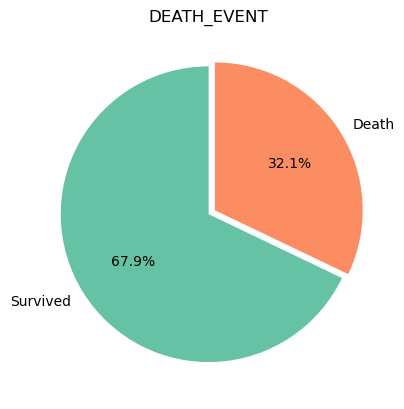

In [12]:
# 'DEATH_EVENT' 컬럼의 분포 확인
counts = df['DEATH_EVENT'].value_counts().sort_index()    # 인덱스 정렬로 0,1 순서 고정
labels = ['Survived', 'Death']    # 라벨 매핑(0: 생존, 1:사망)

# 파이 차트 그리기
plt.pie(counts,
        labels = labels,
        autopct = '%1.1f%%',
        startangle = 90,
        explode = (0, 0.05),
        colors = ['#66c2a5', '#fc8d62']
)
plt.title('DEATH_EVENT')
plt.show()

## 2\) 수치형 변수의 분포 확인

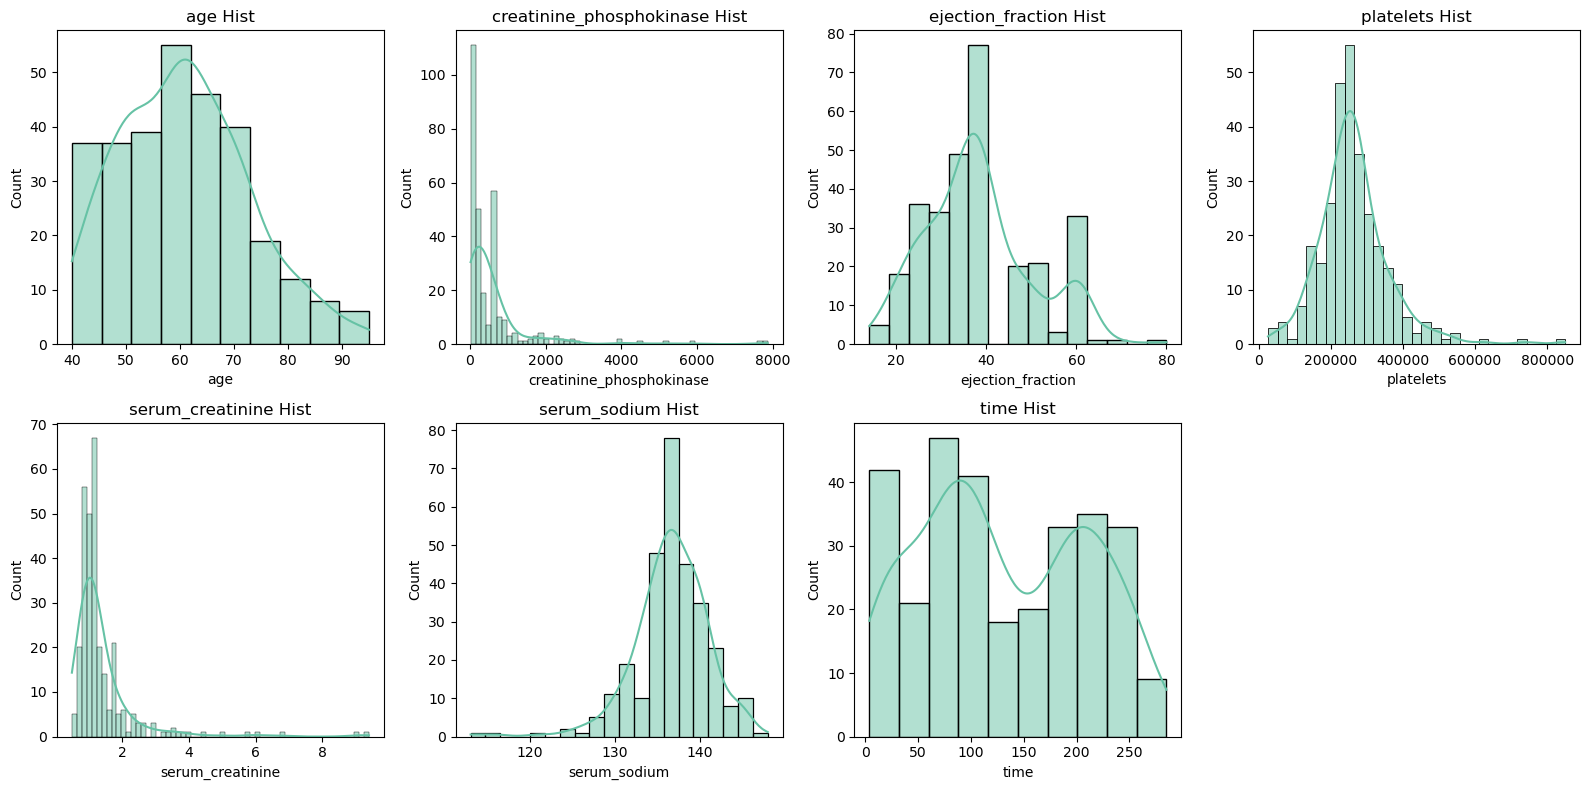

In [13]:
# 수치형 변수만 리스트로 정의
num_features = [
    'age', 'creatinine_phosphokinase', 'ejection_fraction',
    'platelets', 'serum_creatinine', 'serum_sodium', 'time'
]

# 히스토그램 그리기
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#66c2a5')
    axes[i].set_title(f'{col} Hist')

fig.delaxes(axes[7])    # 8번째 칸(인덱스 7)은 변수가 없으므로 비워둡니다

plt.tight_layout()
plt.show()

- `creatinine_phosphokinase`, `serum_creatinine`
  - 오른쪽으로 치우친 분포(Right Skewed)
  - 대다수의 환자는 수치가 낮지만, 몇몇 환자는 수치가 높음

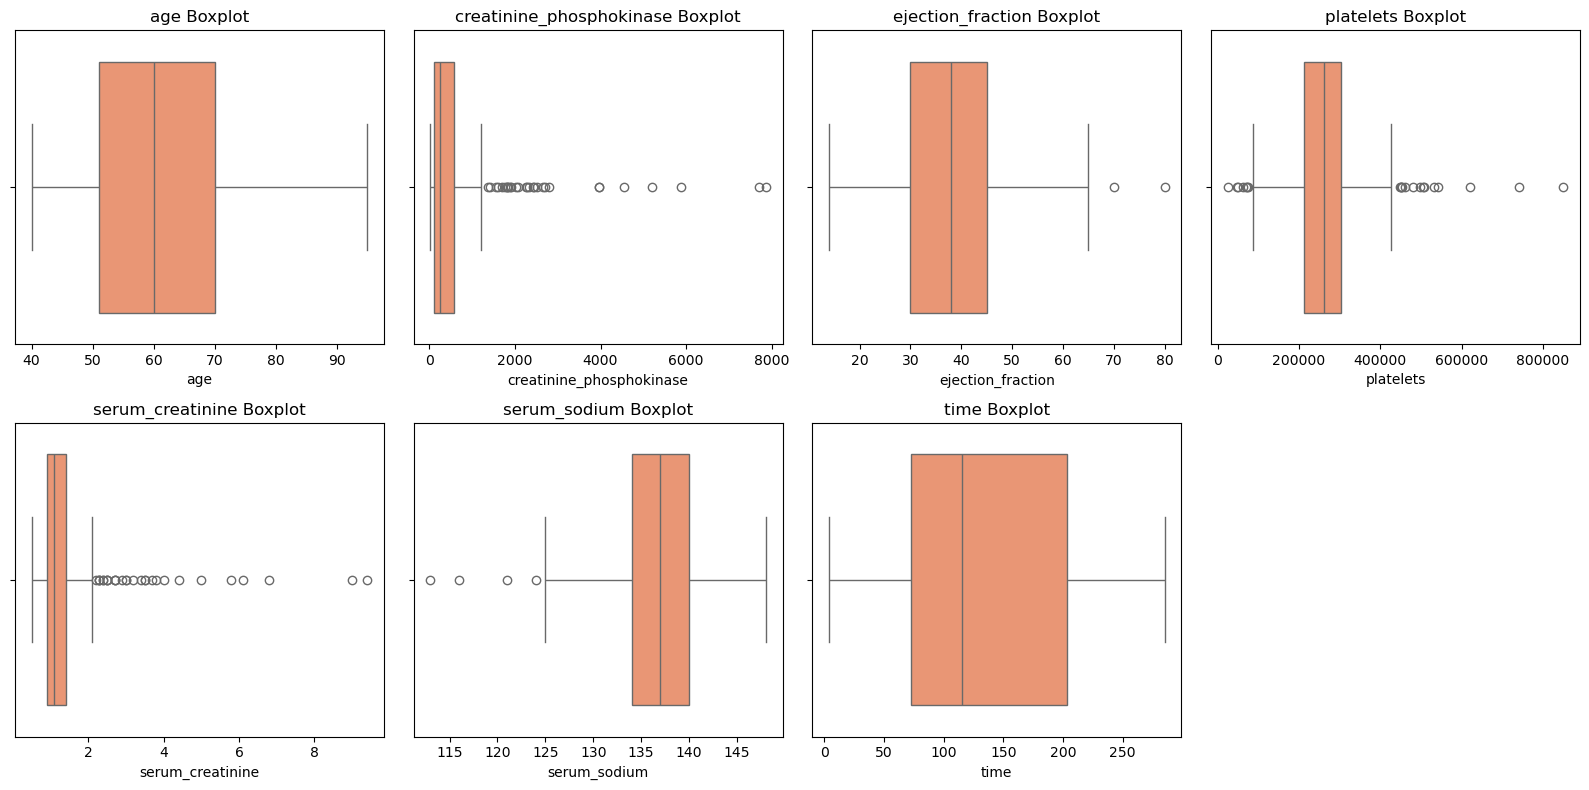

In [14]:
# 박스플롯 그리기 (4행 2열)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(x=df[col], ax=axes[i], color='#fc8d62')
    axes[i].set_title(f'{col} Boxplot')

fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

- `creatinine_phosphokinase`, `serum_creatinine`, `ejection_fraction`
- `serum_sodium`
- `platelets`
  - 이상치 존재
  - 의료 데이터에서 이상치는 '사망 위험이 높은 중증 환자' 를 의미할 수도 있음

## 3\) 범주형 변수의 분포 확인

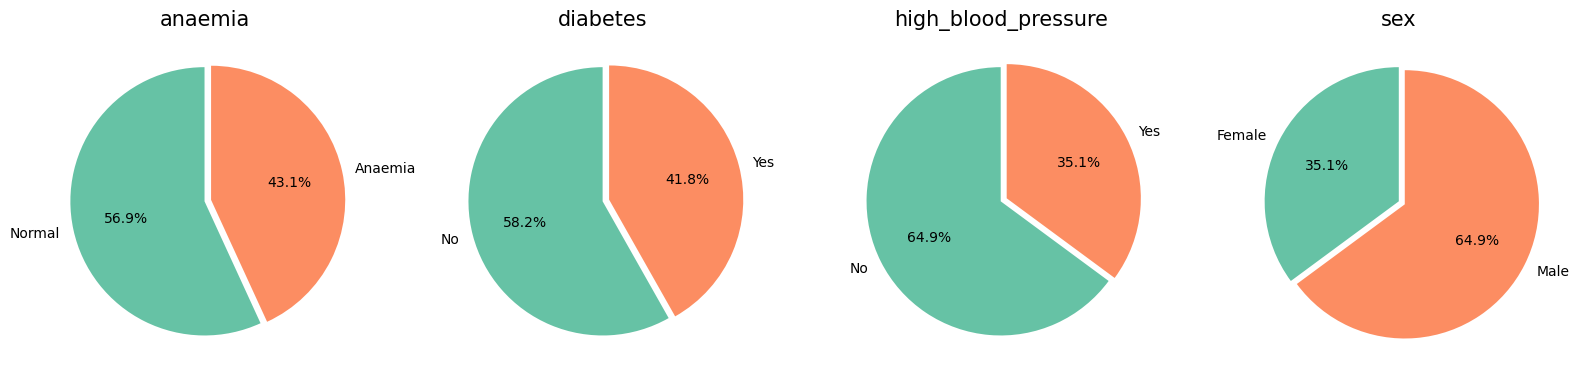

In [15]:
# 범주형 컬럼만 리스트로 정의
categorical_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex']

# 라벨 매핑 (0과 1의 의미를 텍스트로 변환)
labels_map = {
    'anaemia': {0: 'Normal', 1: 'Anaemia'},
    'diabetes': {0: 'No', 1: 'Yes'},
    'high_blood_pressure': {0: 'No', 1: 'Yes'},
    'sex': {0: 'Female', 1: 'Male'}
}

# 3. 1x4 서브플롯 설정
fig, axes = plt.subplots(1, 4, figsize=(16, 8))
axes = axes.flatten() # 1차원으로 펴서 인덱싱 편하게

for i, col in enumerate(categorical_features):
    counts = df[col].value_counts().sort_index()

    # 그래프에 표시할 라벨 리스트 생성
    labels = [labels_map[col][val] for val in counts.index]

    # 파이차트 그리기
    # autopct: 퍼센트 표시 형식 (소수점 첫째 자리까지)
    # explode: 1에 해당하는 조각을 살짝 떼어내서 강조
    axes[i].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90,
                colors=['#66c2a5', '#fc8d62'], explode=(0, 0.05))
    axes[i].set_title(col, fontsize=15)

plt.tight_layout()
plt.show()

## 4\) 상관관계 분석

In [16]:
# (포트폴리오 색감 통일을 위해 set1에서 색상 추출
from matplotlib.colors import LinearSegmentedColormap

set2_colors = plt.get_cmap('Set2').colors
color_red = set2_colors[1]
color_blue = set2_colors[0]

# 음의 상관관계는 파랑, 양의 상관관계는 빨강으로 표현
set2_cmap = LinearSegmentedColormap.from_list(
    'set2_custom', [color_blue, 'white', color_red]
)


**J.Cohen의 효과크기 가이드라인(1988)**
> https://pmc.ncbi.nlm.nih.gov/articles/PMC6618136/

|구간(절대값)|명칭|의학·보건의학에서의 전형적 사용|
|:---:|:---:|---|
|< 0.10|trivial 또는 거의 없음|임상적으로 의미가 없을 가능성이 큼<br>대규모 표본에서만 통계적으로 유의한 경우|
|0.10 - 0.29|small|위험인자-결과 사이의 약한 연관<br>누적/집단 수준에서는 의미가 있을 수 있어 공중보건에서 고려|
|0.30 - 0.49|medium|역학·임상에서 "보통 크기"연관으로 자주 인용<br>임상적 의미가 있을 수 있어 해석 시 강조|
|≥ 0.50|large|의학 데이터에서는 비교적 드물며, 강한 연관으로 간주<br>인과·예측모형에서 핵심 변수 후보|

Cohen(1988)의 기준($r=0.3$: Medium)을 참고하고, 의료 데이터의 다요인적 특성을 고려하여 $r \ge 0.2$인 변수를 주요 분석 대상으로 선정

/tmp/ipykernel_2929/1802465400.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_mask = corr_mat.applymap(lambda x: f"{x:.2f}" if abs(x) >= 0.2 else "")


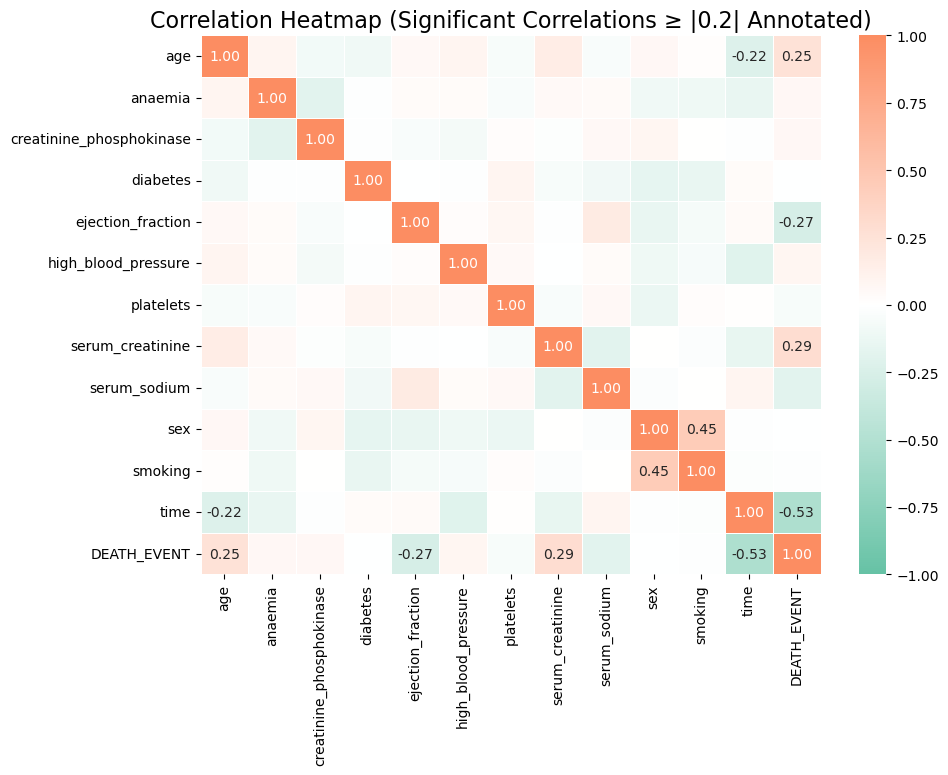

In [17]:
# 상관계수 계산
corr_mat = df.corr()

# 주석(Annotation) 마스크 만들기
# 조건: 절대값이 0.2 이상이면 소수점 둘째 자리까지 문자열로, 아니면 빈 문자열("")
annot_mask = corr_mat.applymap(lambda x: f"{x:.2f}" if abs(x) >= 0.2 else "")

# 히트맵 그리기
# annot 파라미터에 우리가 만든 마스크 행렬 삽입
plt.figure(figsize=(10, 7))
sns.heatmap(corr_mat,
            annot=annot_mask,
            fmt='',
            cmap=set2_cmap,
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5)

plt.title('Correlation Heatmap (Significant Correlations ≥ |0.2| Annotated)', fontsize=16)
plt.show()

1. `time` 오래 생존한 사람일 수록 관찰 기간이 김 → **결과론적 관점**
2. `age` 나이가 많을수록 사망 위험이 높음
3. `serum_creatinine` 신장 기능이 나쁠 수록 사망 위험이 증가함
4. `ejection_fraction` 박출계수가 낮을수록(심장 기능이 떨어질 수록) 사망 위험이 증가함

---

# 3\. 데이터 전처리

<img src='https://github.com/HANISY/AI-Study/blob/main/Projects/02-heartfailure/img/skewed.png?raw=true' width=650 >

<img src="https://github.com/HANISY/AI-Study/blob/main/Projects/02-heartfailure/img/scaler.png?raw=true">

## 1\) 로그 변환

In [18]:
dfs = df.copy()

In [19]:
dfs['creatinine_phosphokinase'] = np.log1p(df['creatinine_phosphokinase'])
dfs['serum_creatinine'] = np.log1p(df['serum_creatinine'])

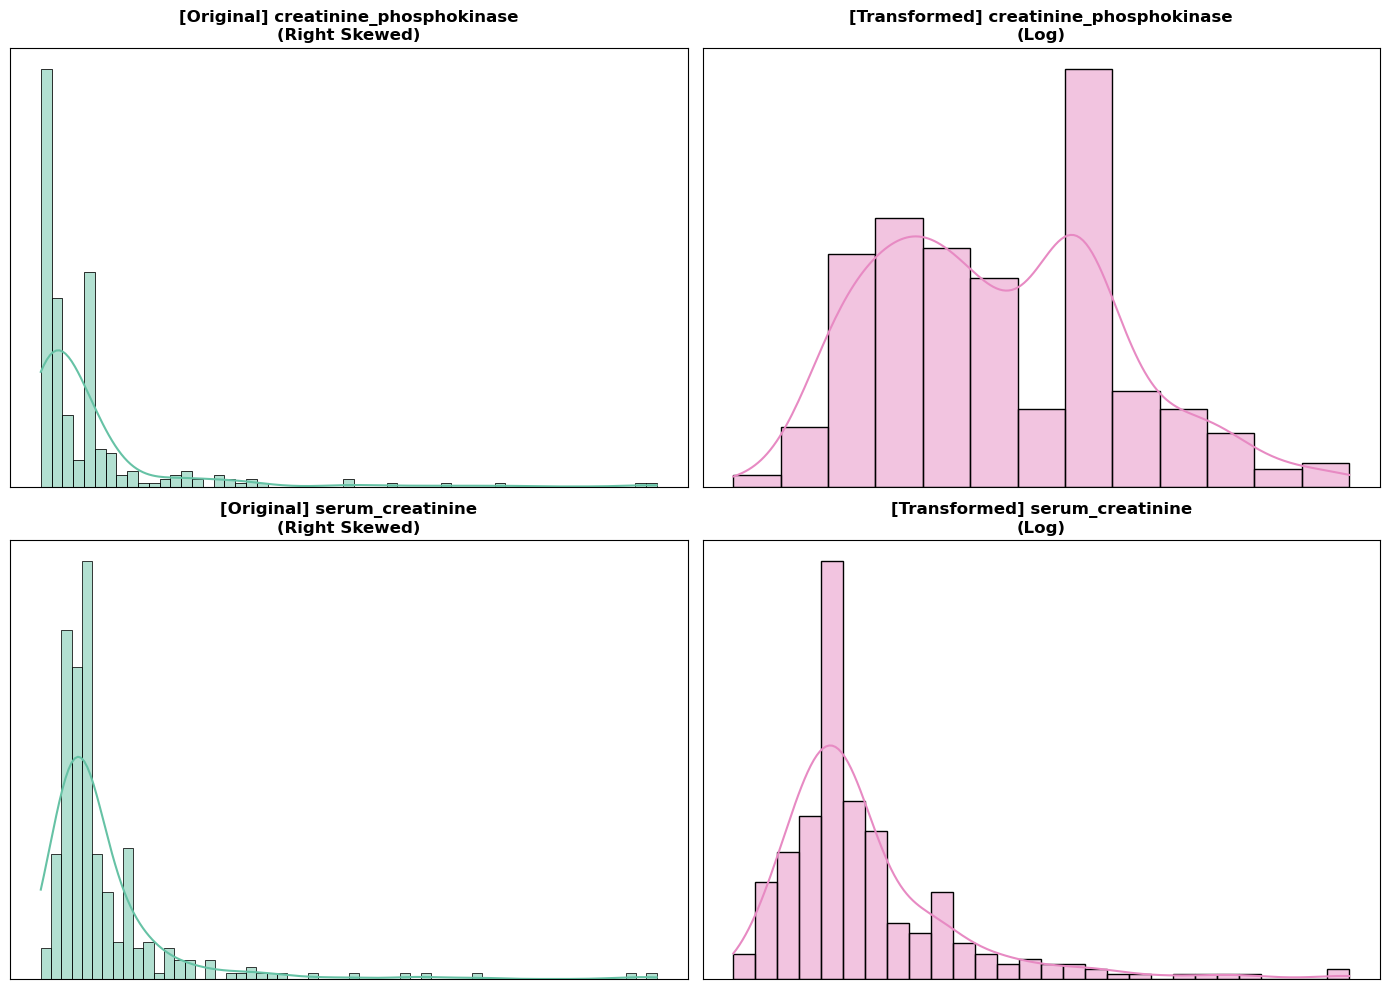

In [20]:
target_cols = ['creatinine_phosphokinase', 'serum_creatinine']

# 그래프 확인
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(target_cols):
    # 왼쪽: 원본 데이터
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='#66c2a5')
    axes[i, 0].set_title(f'[Original] {col}\n(Right Skewed)', fontweight='bold')

    # 왼쪽 그래프 축 제거
    axes[i, 0].set_xticks([]) # X축 눈금 제거
    axes[i, 0].set_yticks([]) # Y축 눈금 제거
    axes[i, 0].set_xlabel('') # X축 라벨 제거
    axes[i, 0].set_ylabel('') # Y축 라벨 제거

    # 오른쪽: 전처리된 데이터
    sns.histplot(dfs[col], kde=True, ax=axes[i, 1], color='#e78ac3')
    axes[i, 1].set_title(f'[Transformed] {col}\n(Log)', fontweight='bold')
    axes[i, 1].set_xlabel('Standardized Score') # X축 라벨 변경

    # 오른쪽 그래프 축 제거
    axes[i, 1].set_xticks([])
    axes[i, 1].set_yticks([])
    axes[i, 1].set_xlabel('')
    axes[i, 1].set_ylabel('')

plt.tight_layout()
plt.show()

**로그 변환 (np.log1p)**
- 로그 변환은 분할 전에 전체 데이터에 미리 적용 가능
- 이유 (독립성): 로그 변환은 내 값($x$)을 그냥 로그값($\log x$)으로 바꾸는 단순 계산<br>
  옆 사람(다른 데이터)이 100이든 1000이든, 내 값이 변하는 데 전혀 영향을 주지 않음
- 비유: 시험장에 들어가기 전에 내가 안경을 쓴다고 시험 문제(데이터 분포)가 유출되지는 않음

## 2\) 데이터 분할

**스케일링 (StandardScaler, RobustScaler)**

- 스케일링은 **반드시 분할 후에 적용**해야 함

- 이유 (의존성): 스케일링을 하려면 평균이나 중앙값 같은 '전체 기준'이 필요합니다.
- 만약 분할 전에 전체 데이터로 평균을 구하면, 미래에 맞춰야 할 정답(Test Set)의 정보가 평균 값에 섞여 들어 감 → **데이터 누수**
- 비유: 내가 1등인지 꼴등인지 알려면 반 친구들의 점수가 필요<br>
  그런데 아직 치르지도 않은 수능 시험지(Test Set)까지 몰래 가져와서 내 등급을 매기면 부정행위(Cheating)이기 때문

In [21]:
# DEATH_EVENT 열을 타깃으로 만들고 나머지 열은 입력 데이터로 사용
dfs_target = dfs['DEATH_EVENT']
dfs_input = dfs.drop(columns='DEATH_EVENT')

In [22]:
# 데이터 세트와 훈련 세트로 구분
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    dfs_input, dfs_target, test_size=0.2, random_state=42, stratify=dfs_target
)

**stratify=dfs_target**
- 역할: 전체 데이터에서 사망자(1)와 생존자(0)의 비율이 만약 3:7이었다면, 훈련 세트와 테스트 세트에서도 똑같이 3:7 비율을 유지하도록 데이터를 분할
- 효과: 테스트 세트에 사망자가 한 명도 안 들어가는 **샘플링 편향** 을 방지

In [23]:
print(train_input.shape, test_input.shape)

(239, 12) (60, 12)


## 3\) 스케일링

|메서드|의미|비유|실제 동작|
|:---:|:---:|---|---|
|fit()|학습 (기준 잡기)|손님의 치수를 재는 과정|데이터의 평균($\mu$)과 표준편차($\sigma$)를 계산해서 기억|
|transform()|적용 (변환하기)|잰 치수를 바탕으로 옷감을 자르는 과정|기억해둔 평균/표준편차 공식에 맞춰 데이터 값을 실제로 변경|
|fit_transform()|학습 + 적용|치수를 재고 바로 옷감을 자르는 과정을 한 번에|평균/표준편차를 계산하고 바로 적용 (효율적)|

In [24]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# 범주형 변수(스케일러 미적용) 유지를 위해 복사본 생성
train_scaled = train_input.copy()
test_scaled = test_input.copy()

# 컬럼 그룹 나누기
robust_dfs = ['platelets', 'ejection_fraction', 'serum_sodium']
std_dfs = ['age', 'time', 'creatinine_phosphokinase', 'serum_creatinine']

# 스케일러 객체 생성
rs = RobustScaler()
ss = StandardScaler()

# 훈련 세트 전처리
train_scaled[robust_dfs] = rs.fit_transform(train_input[robust_dfs])
train_scaled[std_dfs] = ss.fit_transform(train_input[std_dfs])

# 테스트 세트 전처리
test_scaled[robust_dfs] = rs.transform(test_input[robust_dfs])
test_scaled[std_dfs] = ss.transform(test_input[std_dfs])

# 4\. 모델링

## 1\) 로지스틱 회귀

In [25]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.8619246861924686
0.8166666666666667


In [26]:
# 로지스틱 회귀가 학습한 계수와 절편을 출력
print(lr.coef_, lr.intercept_)

[[ 0.37728404  0.2474337   0.37996581  0.43257488 -1.00942145  0.19412383
  -0.13409523  0.83841594 -0.08715249 -0.35082576  0.24715481 -1.59513514]] [-1.57284757]


/tmp/ipykernel_2929/3419925451.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=coef_df, palette=colors)


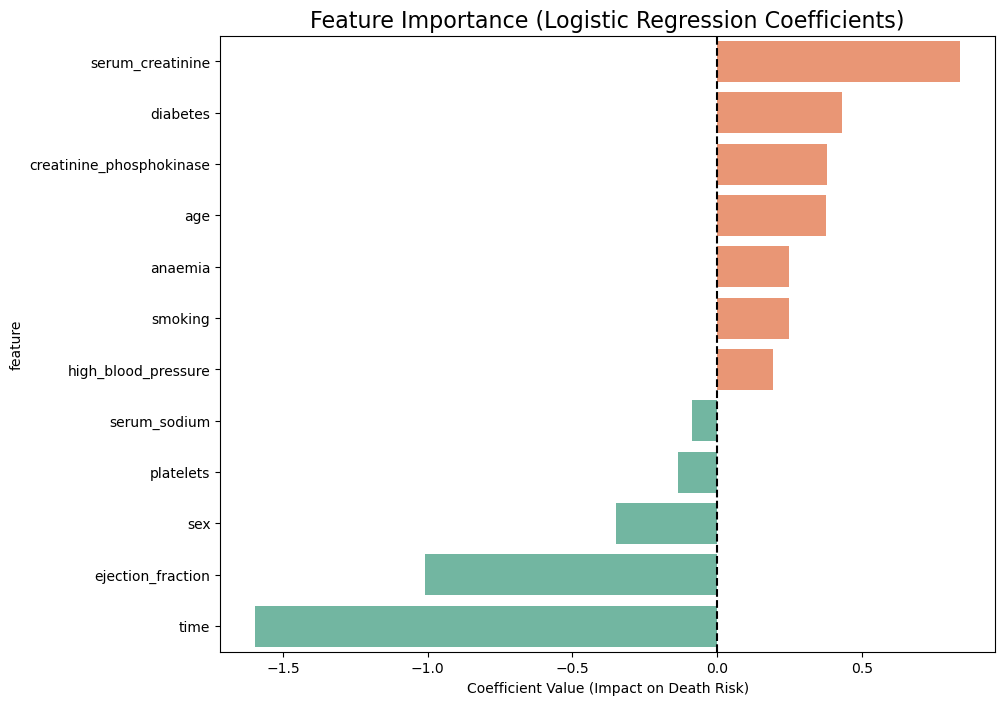

                     feature  coefficient
7           serum_creatinine     0.838416
3                   diabetes     0.432575
2   creatinine_phosphokinase     0.379966
0                        age     0.377284
1                    anaemia     0.247434
10                   smoking     0.247155
5        high_blood_pressure     0.194124
8               serum_sodium    -0.087152
6                  platelets    -0.134095
9                        sex    -0.350826
4          ejection_fraction    -1.009421
11                      time    -1.595135


In [27]:
# 계수와 변수명 연결하기
# lr.coef_는 2차원 배열이라 [0]으로 추출
coef_df = pd.DataFrame({
    'feature': train_scaled.columns,
    'coefficient': lr.coef_[0]
})

# 영향력 순서대로 정렬 (절대값 기준이 아니라 부호 포함해서)
coef_df = coef_df.sort_values(by='coefficient', ascending=False)

# 막대그래프 시각화
plt.figure(figsize=(10, 8))
# 색상 구분: 양수는 빨강(위험), 음수는 파랑(안전)
colors = ['#fc8d62' if c > 0 else '#66c2a5' for c in coef_df['coefficient']]

sns.barplot(x='coefficient', y='feature', data=coef_df, palette=colors)
plt.title('Feature Importance (Logistic Regression Coefficients)', fontsize=16)
plt.xlabel('Coefficient Value (Impact on Death Risk)')
plt.axvline(x=0, color='black', linestyle='--') # 0 기준선
plt.show()

# 수치 확인
print(coef_df)

- `ejection_fraction`(-1.00)은 생존에 가장 강력한 긍정적 영향을, `serum_creatinine`(0.83)은 사망에 가장 큰 부정적 영향을 미치는 것으로 나타남
- 절편이 음수(-1.57)라는 것은, 딱히 나쁜 지표가 없는 평균적인 환자라면, 기본적으로 생존(0)할 확률이 사망(1)할 확률보다 훨씬 높다는 것을 나타냄

### 시간변수를 제거한 로지스틱 회귀

In [28]:
# 입력 데이터에서 'time' 변수 제거
dfs_no_time = dfs_input.drop(columns=['time'])
dfs_no_time_target = dfs_target

# 데이터 분할
train_input, test_input, train_target, test_target = train_test_split(
    dfs_no_time, dfs_no_time_target, test_size=0.2, random_state=42, stratify=dfs_no_time_target
)

# 범주형 변수(스케일러 미적용) 유지를 위해 복사본 생성
train_scaled = train_input.copy()
test_scaled = test_input.copy()

# 컬럼 그룹 나누기
robust_dfs = ['platelets', 'ejection_fraction', 'serum_sodium']
std_dfs = ['age', 'creatinine_phosphokinase', 'serum_creatinine']

# 스케일러 객체 생성
rs = RobustScaler()
ss = StandardScaler()

# 훈련 세트 전처리
train_scaled[robust_dfs] = rs.fit_transform(train_input[robust_dfs])
train_scaled[std_dfs] = ss.fit_transform(train_input[std_dfs])

# 테스트 세트 전처리
test_scaled[robust_dfs] = rs.transform(test_input[robust_dfs])
test_scaled[std_dfs] = ss.transform(test_input[std_dfs])

# 로지스틱 회귀 모델 학습
lr_no_time = LogisticRegression()
lr_no_time.fit(train_scaled, train_target)

# 결과 확인
print(lr_no_time.score(train_scaled, train_target))
print(lr_no_time.score(test_scaled, test_target))

0.7740585774058577
0.7166666666666667


/tmp/ipykernel_2929/3990178497.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=coef_df, palette=colors)


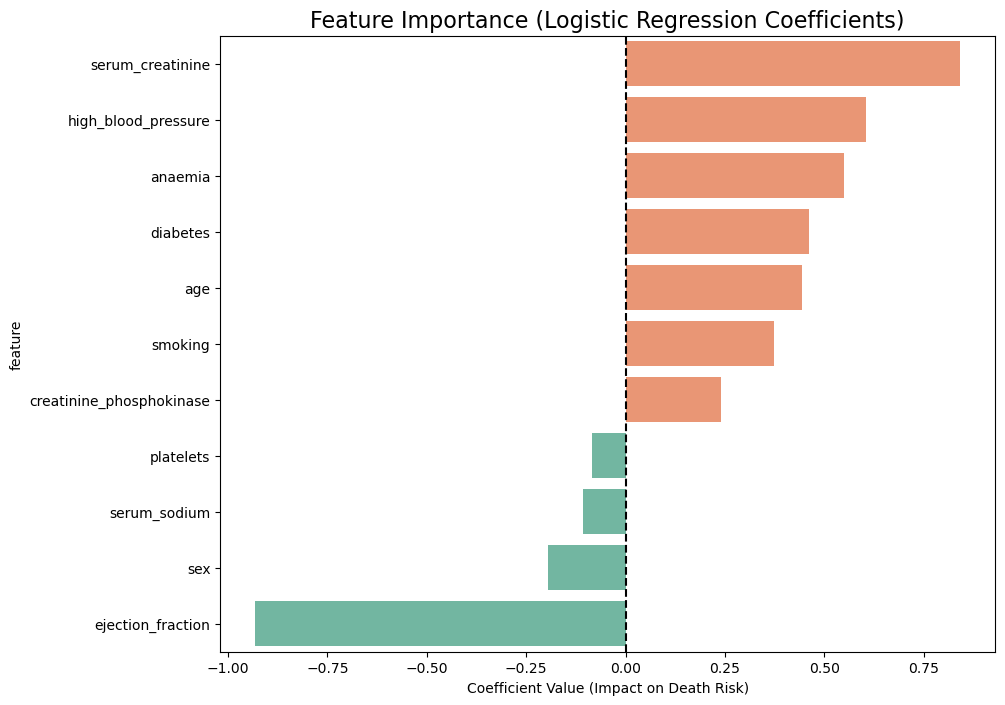

                     feature  coefficient
7           serum_creatinine     0.841228
5        high_blood_pressure     0.605581
1                    anaemia     0.549521
3                   diabetes     0.461524
0                        age     0.443317
10                   smoking     0.374239
2   creatinine_phosphokinase     0.239673
6                  platelets    -0.085002
8               serum_sodium    -0.106207
9                        sex    -0.195146
4          ejection_fraction    -0.931030


In [29]:
coef_df = pd.DataFrame({
    'feature': train_scaled.columns,
    'coefficient': lr_no_time.coef_[0]
})

# 영향력 순서대로 정렬 (절대값 기준이 아니라 부호 포함해서)
coef_df = coef_df.sort_values(by='coefficient', ascending=False)

# 막대그래프 시각화
plt.figure(figsize=(10, 8))
# 색상 구분: 양수는 빨강(위험), 음수는 파랑(안전)
colors = ['#fc8d62' if c > 0 else '#66c2a5' for c in coef_df['coefficient']]

sns.barplot(x='coefficient', y='feature', data=coef_df, palette=colors)
plt.title('Feature Importance (Logistic Regression Coefficients)', fontsize=16)
plt.xlabel('Coefficient Value (Impact on Death Risk)')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

# 수치 확인
print(coef_df)

### 확률적 경사 하강법
데이터가 너무 적기 때문에 비효율적

In [30]:
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', max_iter=100, random_state=42)

sc.fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.7238493723849372
0.7166666666666667


## 2\) 결정 트리 모델

In [31]:
# 결정 트리 모델 훈련
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

dt.fit(train_input, train_target)
print(dt.score(train_input, train_target))     # 훈련 세트
print(dt.score(test_input, test_target))       # 테스트 세트

1.0
0.7166666666666667


테스트 세트의 점수가 훈련 세트의 점수보다 낮다 = '**과대적합**'

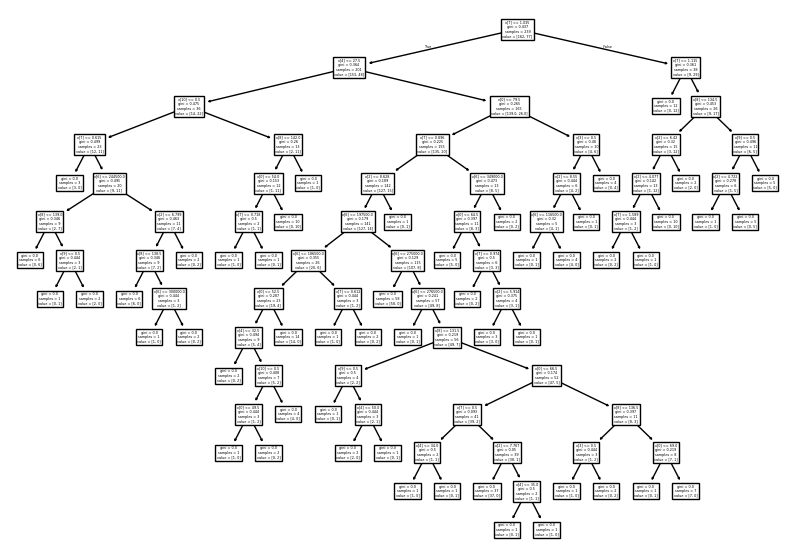

In [32]:
# 결정 트리 모델을 그림으로 표현
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,7))
plot_tree(dt)
plt.show()

### 최적의 Depth 찾기

In [33]:
print("Depth\tTrain Score\tTest Score")
print("-" * 30)

# depth를 2부터 7까지 바꿔가며 테스트
for depth in range(2, 8):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(train_input, train_target)

    print(f"{depth}\t{dt.score(train_input, train_target):.4f}\t\t{dt.score(test_input, test_target):.4f}")

Depth	Train Score	Test Score
------------------------------
2	0.7950		0.7167
3	0.8117		0.7833
4	0.8577		0.7167
5	0.8912		0.7167
6	0.9163		0.7333
7	0.9372		0.7333


In [34]:
# 모델 단순화
dt = DecisionTreeClassifier(max_depth=3, random_state=42)

# 모델 학습
dt.fit(train_input, train_target)
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))

0.8117154811715481
0.7833333333333333


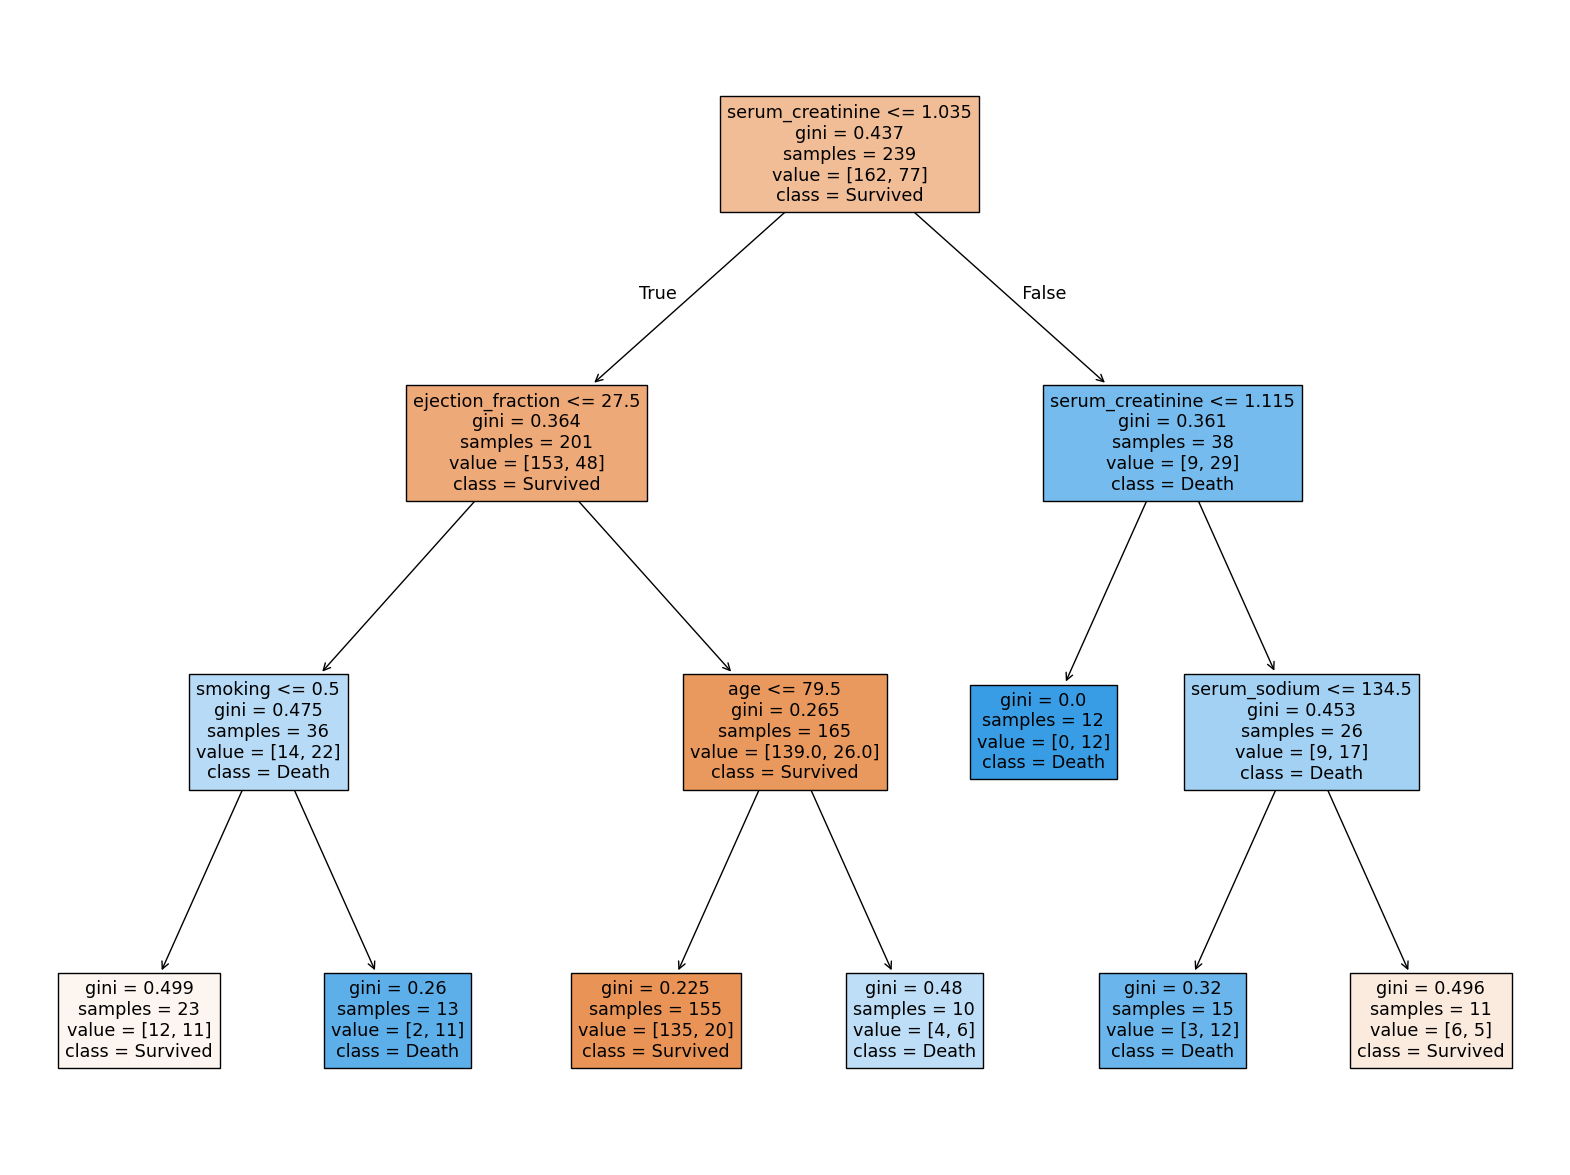

In [35]:
# 시각화
plt.figure(figsize=(20, 15))
plot_tree(dt, filled=True, feature_names=train_input.columns, class_names=['Survived', 'Death'])
plt.show()

1.0
0.7166666666666667


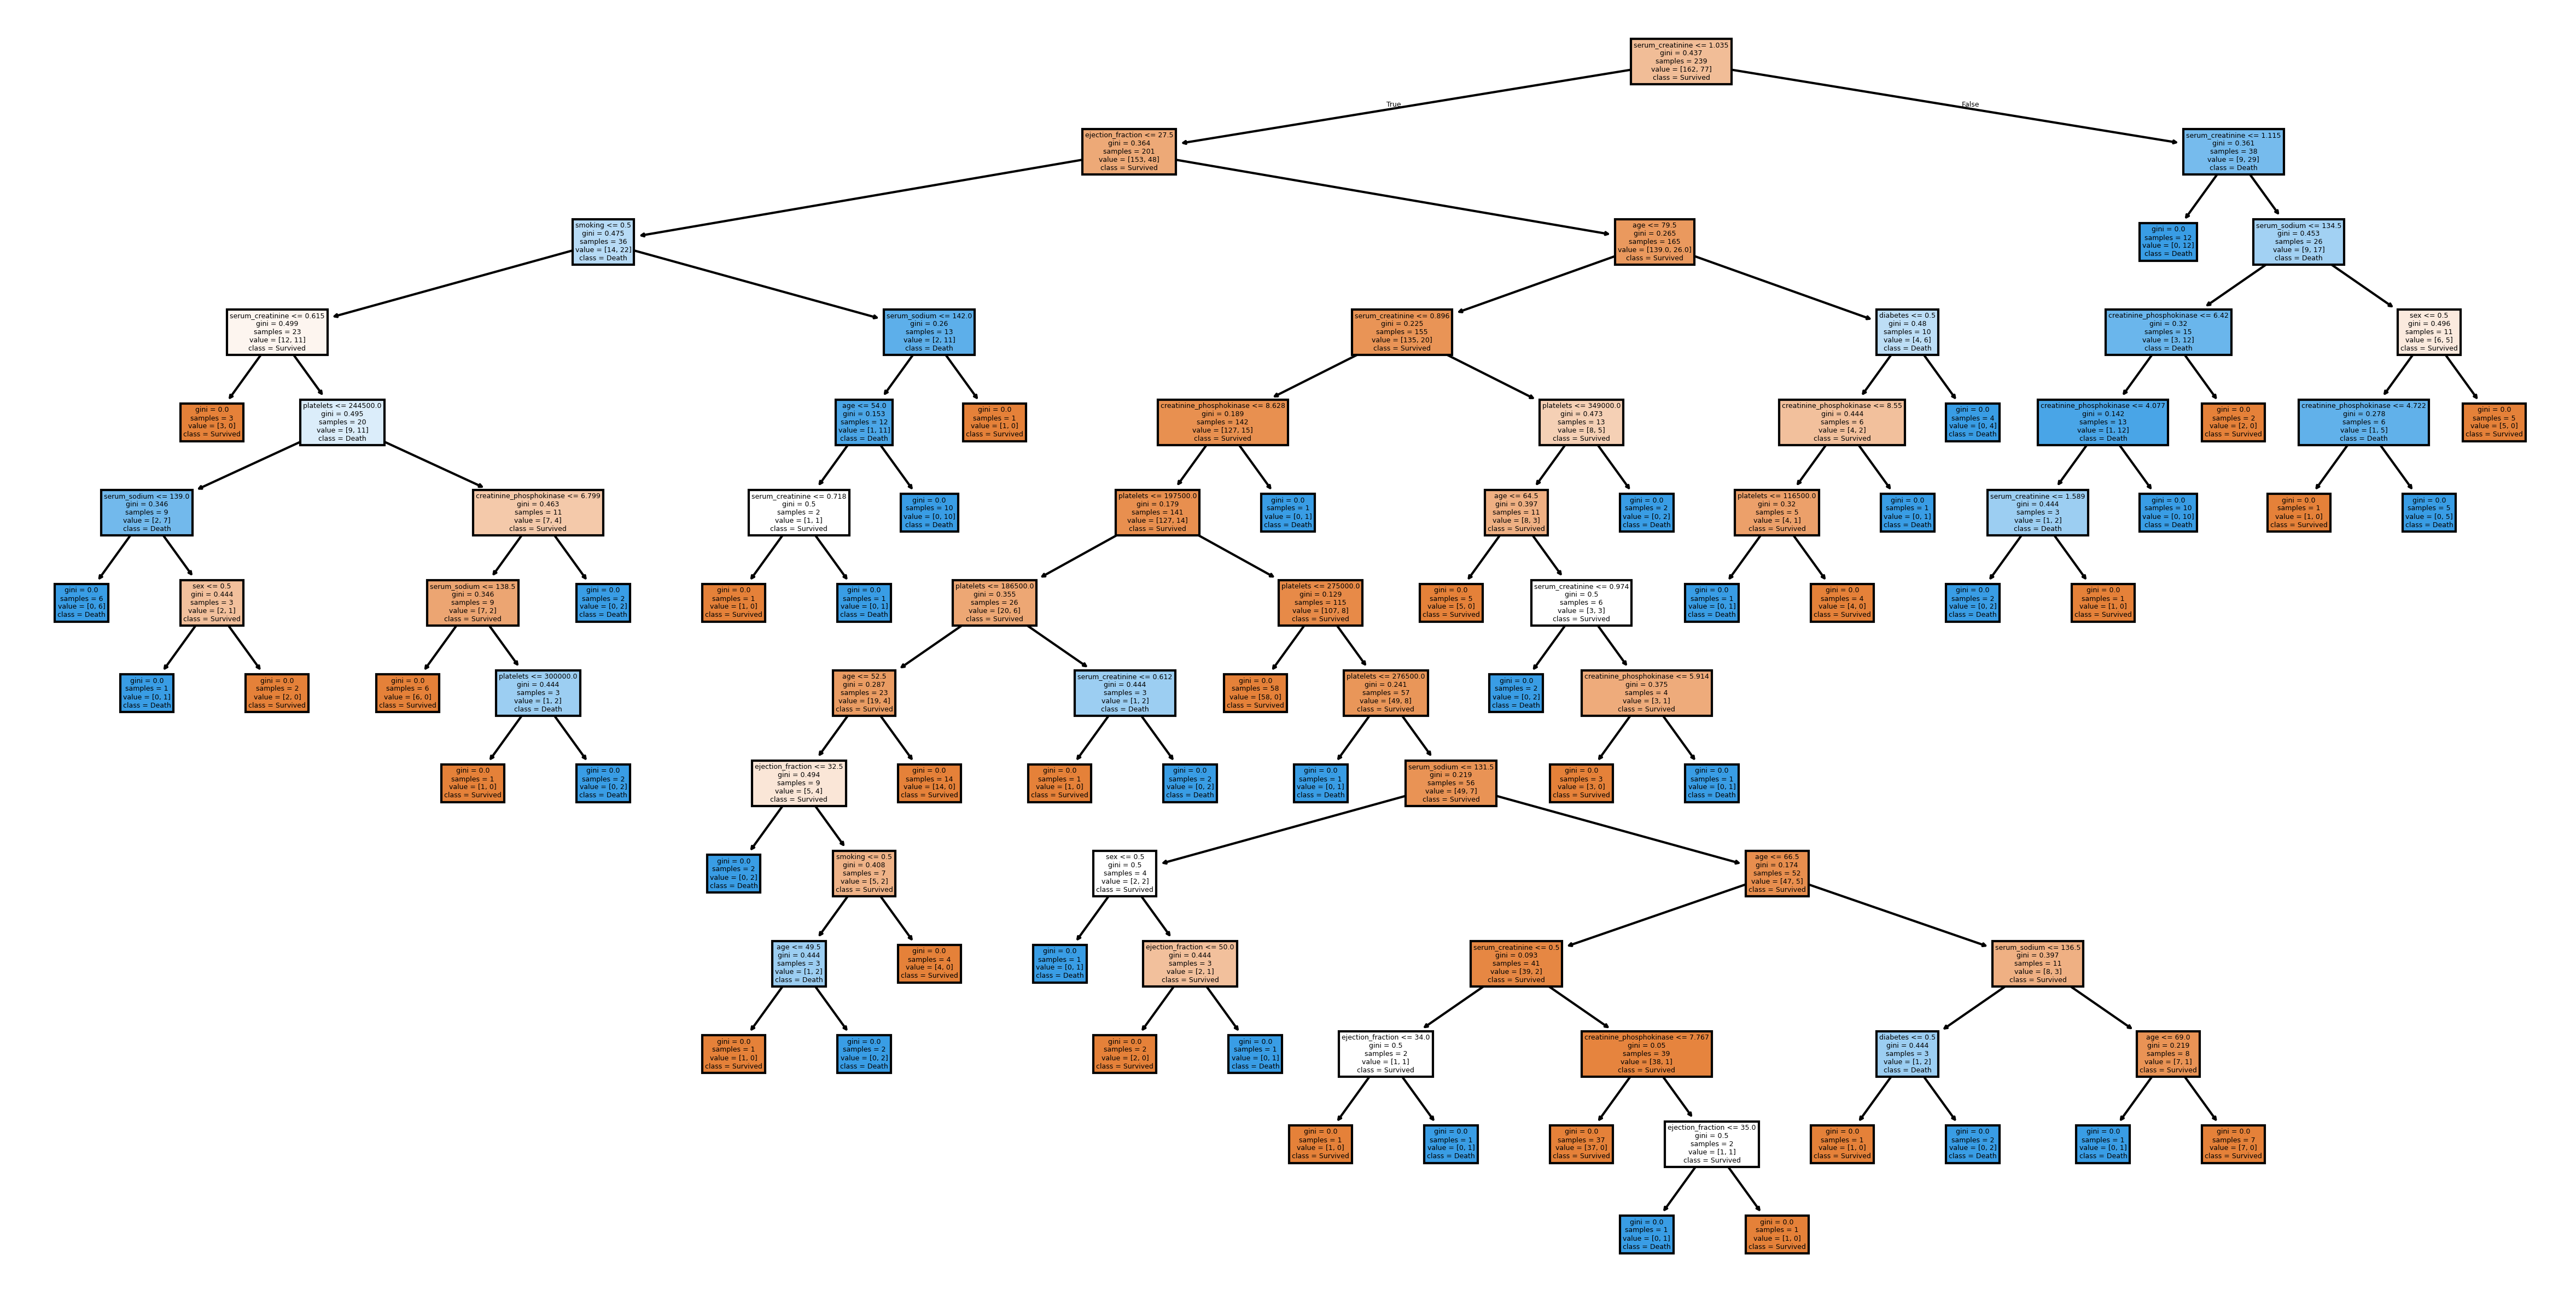

In [36]:
# 0.0005만큼 불순도가 안 들어줄면 분할 금지
dt = DecisionTreeClassifier(min_impurity_decrease=0.0005, random_state=42)

# 모델 학습
dt.fit(train_input, train_target)

# 점수 확인
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))

# 시각화
plt.figure(figsize=(20,10), dpi=300)
plot_tree(dt, filled=True, feature_names=train_input.columns, class_names=['Survived', 'Death'])
plt.show()

### 특성 중요도

특성 중요도 순위
                     Feature  Importance
7           serum_creatinine    0.277780
4          ejection_fraction    0.163607
0                        age    0.119575
2   creatinine_phosphokinase    0.117255
6                  platelets    0.109684
8               serum_sodium    0.087305
9                        sex    0.055447
10                   smoking    0.036136
3                   diabetes    0.033210
1                    anaemia    0.000000
5        high_blood_pressure    0.000000


/tmp/ipykernel_2929/2955382980.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='Set2')


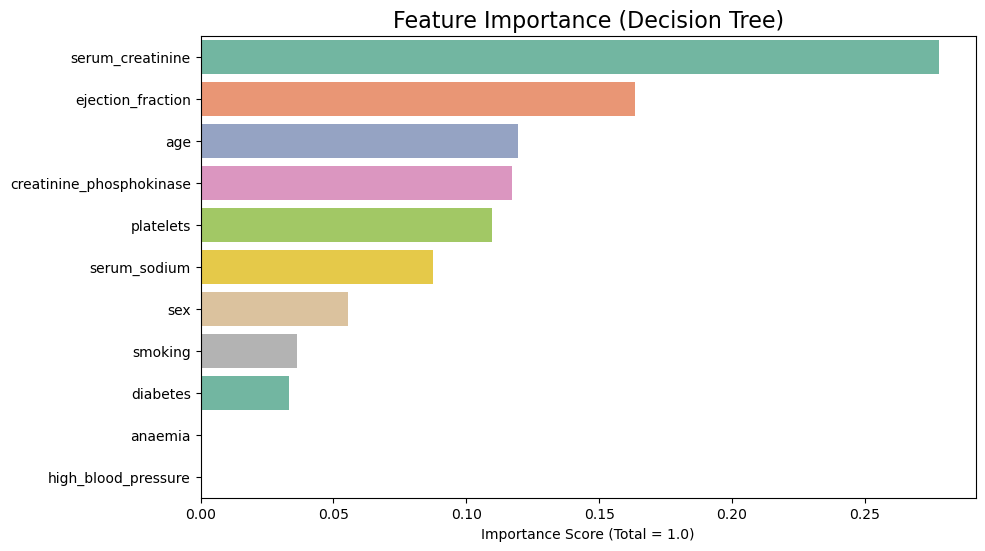

In [37]:
# 변수명과 중요도 매핑
fi_df = pd.DataFrame({
    'Feature': train_input.columns,
    'Importance': dt.feature_importances_
})

# 중요도 순서대로 내림차순 정렬
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# 3. 수치로 확인
print("특성 중요도 순위")
print(fi_df)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='Set2')

plt.title('Feature Importance (Decision Tree)', fontsize=16)
plt.xlabel('Importance Score (Total = 1.0)')
plt.ylabel('')
plt.show()

특성 중요도 TOP 5
                    Feature  Importance
7          serum_creatinine    0.277780
4         ejection_fraction    0.163607
0                       age    0.119575
2  creatinine_phosphokinase    0.117255
6                 platelets    0.109684


/tmp/ipykernel_2929/2211099699.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top5_fi, palette='Set2')


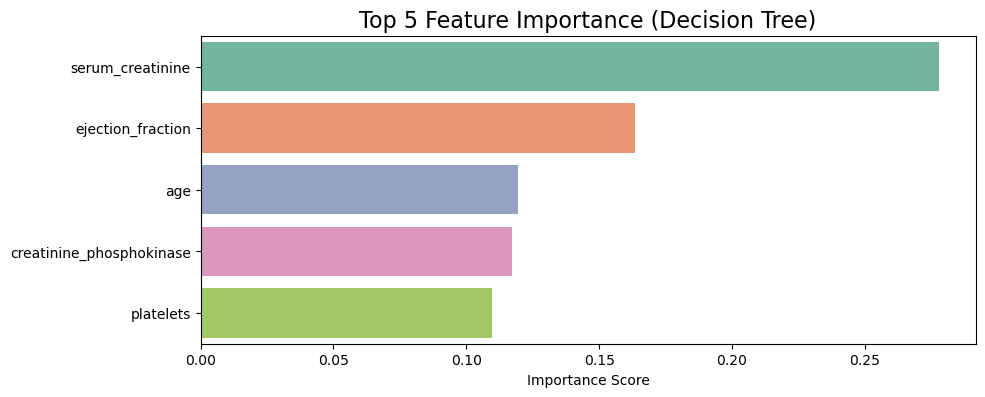

In [38]:
# 1. 변수명과 중요도 매핑
fi_df = pd.DataFrame({
    'Feature': train_input.columns,
    'Importance': dt.feature_importances_
})

# 2. 중요도 순서대로 내림차순 정렬
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# -------------------------------------------------------
# [수정] 상위 5개만 추출
top5_fi = fi_df.head(5)
# -------------------------------------------------------

# 3. 수치로 확인 (상위 5개만 출력)
print("특성 중요도 TOP 5")
print(top5_fi)

# 4. 시각화
plt.figure(figsize=(10, 4))

# data 파라미터에 전체 데이터(fi_df) 대신 상위 5개(top5_fi)를 넣습니다.
sns.barplot(x='Importance', y='Feature', data=top5_fi, palette='Set2')

plt.title('Top 5 Feature Importance (Decision Tree)', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('', fontsize=1)
plt.show()

/tmp/ipykernel_2929/2218161977.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_counts = df.groupby(['age_group', 'DEATH_EVENT']).size().unstack(fill_value=0)


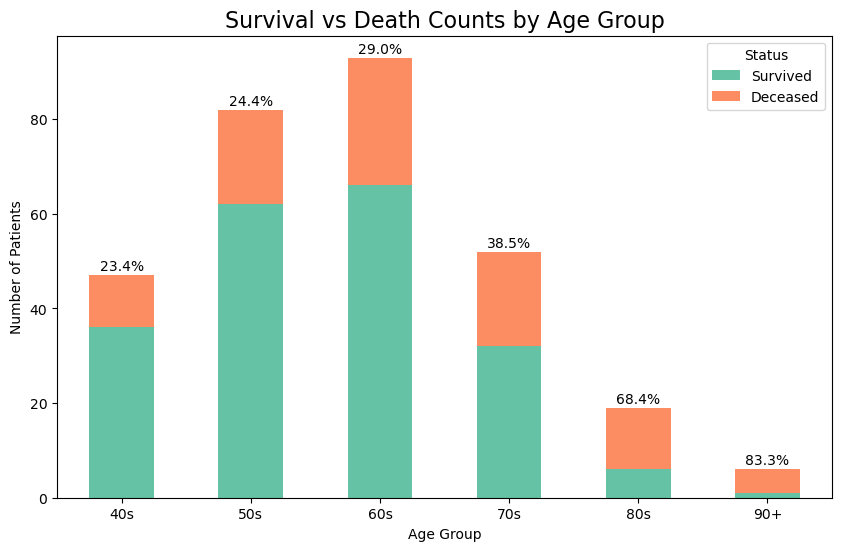

In [39]:
# 연령대 구분: 40대부터 90대까지 구간 설정
bins = [40, 50, 60, 70, 80, 90, 100]
labels = ['40s', '50s', '60s', '70s', '80s', '90+']

# pd.cut: 연속적인 나이 숫자를 구간별로 자르는 함수
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# 그룹별 집계
age_group_counts = df.groupby(['age_group', 'DEATH_EVENT']).size().unstack(fill_value=0)

# 시각화
colors = ['#66c2a5', '#fc8d62']

ax = age_group_counts.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)

plt.title('Survival vs Death Counts by Age Group', fontsize=16)
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.legend(['Survived', 'Deceased'], title='Status')

# 사망률(%) 계산 및 표시
totals = age_group_counts.sum(axis=1)
death_rates = (age_group_counts[1] / totals * 100).fillna(0)

for i, rate in enumerate(death_rates):
    if totals.iloc[i] > 0: # 데이터가 있는 경우만
        plt.text(i, totals.iloc[i] + 1, f'{rate:.1f}%', ha='center', color='black')

plt.show()

# 수치 데이터 확인
# print("=== 연령대별 사망률 현황 ===")
# print(pd.concat([age_group_counts, death_rates.rename('Death Rate (%)')], axis=1))

`age`는 통상적으로 가장 강력한 사망 위험 인자이나, 본 데이터셋은 고령의 심부전 환자 위주로 구성되어 있어 나이 변수의 변별력이 상대적으로 낮음

이에 따라, 모델은 단순한 생물학적 연령보다는 신장 기능`serum_creatinine`과 심장 기능`ejection_fraction` 같은 '실질적인 장기 부전 지표'를 사망의 더 직접적인 원인으로 지목한 것으로 예측

## 3\) 모델 최적화

### 교차 검증

In [40]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# 훈련 세트를 섞은 후 10-폴드 교차 검증 수행
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_validate(dt, train_input, train_target, cv=splitter)

print(f"개별 점수: {np.round(scores['test_score'],2)}")
print(f"평균 점수: {np.mean(scores['test_score']):.2f}")

개별 점수: [0.67 0.79 0.58 0.75 0.67 0.67 0.58 0.5  0.58 0.74]
평균 점수: 0.65


### 그리드서치

In [41]:
# 탐색할 매개변수와 탐색할 값의 리스트를 딕셔너리로 구성
from sklearn.model_selection import GridSearchCV
params = {'min_impurity_decrease': [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]}

# 그리드 서치 객체 생성
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)

# 그리드 서치 수행
gs.fit(train_input, train_target)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'min_impurity_decrease': [0.0001, 0.0002, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [42]:
# 가장 점수가 높았던 파라미터 확인
print(gs.best_params_)

{'min_impurity_decrease': 0.0001}


In [43]:
# 5번의 교차 검증으로 얻은 점수를 출력
print(gs.cv_results_['mean_test_score'])

[0.66533688 0.66533688 0.66533688 0.66533688 0.66533688]


In [44]:
# best_index_ 속성을 사용해 얻은 가장 높은 인덱스로 params 키에 저장된 매개 변수 출력
print(gs.cv_results_['params'][gs.best_index_])

{'min_impurity_decrease': 0.0001}


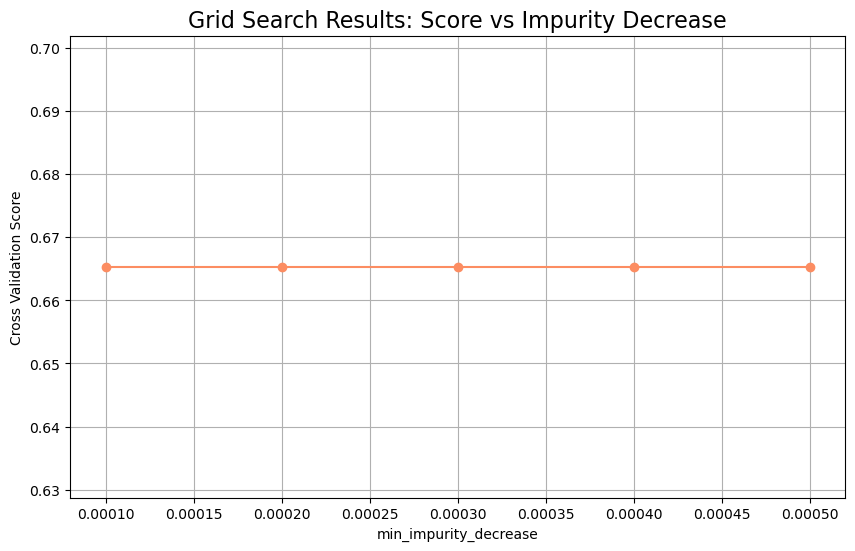

In [45]:
# 테스트한 파라미터 값 (X축)
params = gs.cv_results_['param_min_impurity_decrease'].data

# 그떄의 평균 점수 (Y축)
scores = gs.cv_results_['mean_test_score']

# 그래프로 확인
plt.figure(figsize=(10, 6))
plt.plot(params, scores, marker='o', linestyle='-', color='#fc8d62')

plt.title('Grid Search Results: Score vs Impurity Decrease', fontsize=16)
plt.xlabel('min_impurity_decrease')
plt.ylabel('Cross Validation Score')
plt.grid(True)
plt.show()

범위가 너무 좁아서 변화가 관찰되지 않는 상태

In [46]:
dt = gs.best_estimator_
print(f"훈련 세트: {dt.score(train_input, train_target)}")
print(f"테스트 세트: {dt.score(test_input, test_target)}")

훈련 세트: 1.0
테스트 세트: 0.7166666666666667


과대적합을 보임

In [47]:
# 탐색할 하이퍼파라미터 범위 재설정 (과대적합 방지 및 최적화)
params = {'min_impurity_decrease': np.arange(0.0001, 0.02, 0.0001),
          'max_depth': range(3, 15, 1),
          'min_samples_split': range(2, 100, 10)
          }

# 그리드 서치 객체 생성
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)

# 모델 훈련
gs.fit(train_input, train_target)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': range(3, 15), 'min_impurity_decrease': array([0.0001...0198, 0.0199]), 'min_samples_split': range(2, 100, 10)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [48]:
# 가장 성능이 좋은 파라미터 확인
print(gs.best_params_)

{'max_depth': 3, 'min_impurity_decrease': np.float64(0.0001), 'min_samples_split': 52}


In [49]:
# 최상의 교차 검증 점수 확인
print(np.max(gs.cv_results_['mean_test_score']))

0.7573581560283689


In [50]:
# 과대적합 해소 여부 점검
dt = gs.best_estimator_
print(f"훈련 세트: {dt.score(train_input, train_target)}")
print(f"테스트 세트: {dt.score(test_input, test_target)}")

훈련 세트: 0.803347280334728
테스트 세트: 0.7833333333333333


### 랜덤서치

In [51]:
from sklearn.model_selection import RandomizedSearchCV
rs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), params,
                        n_iter=100, n_jobs=-1, random_state=42)         # 샘플링 횟수는 n_iter 매개 변수에 지정
rs.fit(train_input, train_target)

,estimator,DecisionTreeC...ndom_state=42)
,param_distributions,"{'max_depth': range(3, 15), 'min_impurity_decrease': array([0.0001...0198, 0.0199]), 'min_samples_split': range(2, 100, 10)}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [52]:
# 최적의 매개변수 조합 출력
print(rs.best_params_)

{'min_samples_split': 92, 'min_impurity_decrease': np.float64(0.0077), 'max_depth': 3}


In [53]:
# 최고의 교차 검증 점수 확인
print(np.max(rs.cv_results_['mean_test_score']))

0.7573581560283689


In [54]:
# 테스트 세트 성능 확인
dt = rs.best_estimator_
print(dt.score(test_input, test_target))

0.7833333333333333


## 4\) 앙상블 학습

### 랜덤포레스트

In [55]:
# 교차 검증 수행
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(rf, train_input, train_target,
                        return_train_score=True, n_jobs=-1)     # 검증 점수뿐만 아니라 훈련 세트에 대한 점수도 같이 반환
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7491134751773049


In [56]:
# 랜덤포레스트 모델 훈련
rf.fit(train_input, train_target)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


/tmp/ipykernel_2929/563156056.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='Set2')


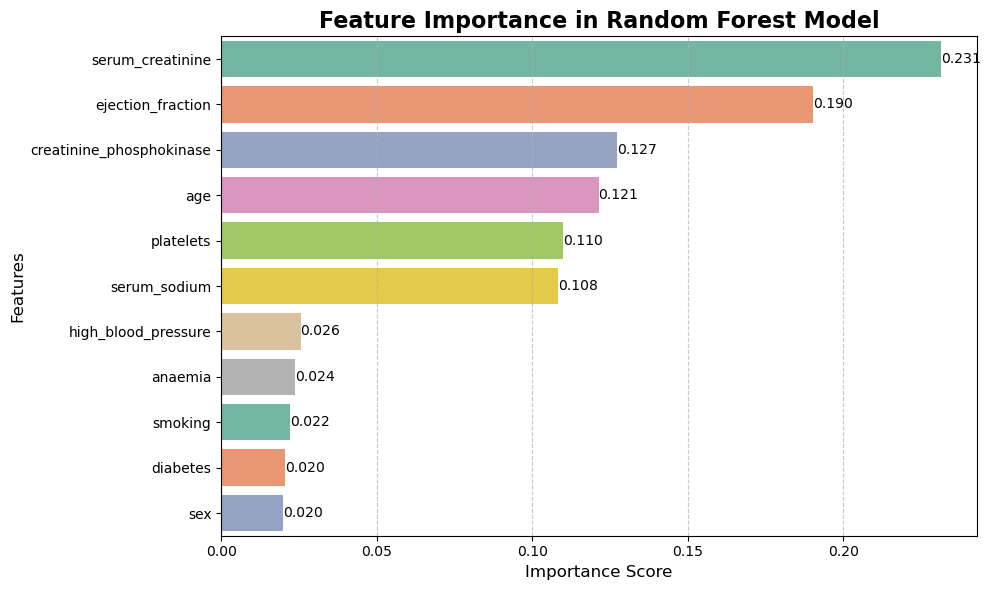

In [57]:
# 특성 이름과 중요도 점수를 묶어서 데이터프레임으로 생성
fi_df = pd.DataFrame({
    'Feature': train_input.columns,        # 특성 이름들
    'Importance': rf.feature_importances_  # 계산된 중요도 값
}).sort_values(by='Importance', ascending=False) # 높은 순으로 정렬

# 막대 그래프 그리기
plt.figure(figsize=(10, 6))

sns.barplot(x='Importance', y='Feature', data=fi_df, palette='Set2')

# 그래프 제목 및 라벨 설정
plt.title('Feature Importance in Random Forest Model', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# 값 표시하기
for index, value in enumerate(fi_df['Importance']):
    plt.text(value, index, f'{value:.3f}', va='center', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.7) # 가로 눈금선 추가
plt.tight_layout() # 여백 자동 정리
plt.show()

In [58]:
# OOB 점수 출력
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)
rf.fit(train_input, train_target)
print(rf.oob_score_)

0.7573221757322176


### 엑스트라 트리

In [59]:
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(et, train_input, train_target,
                        return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7365248226950355


/tmp/ipykernel_2929/348382938.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_score, palette='Set2')


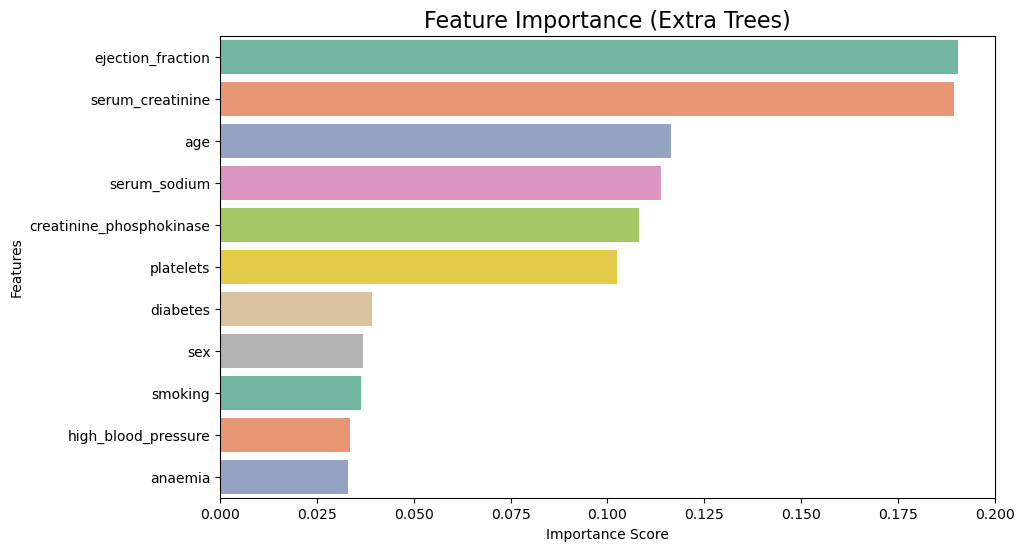

In [60]:
# 엑스트라 트리 모델에서의 특성 중요도 확인
# 특성 이름과 중요도 매칭
et.fit(train_input, train_target)

feature_scores = pd.Series(et.feature_importances_, index=train_input.columns)
feature_scores = feature_scores.sort_values(ascending=False)

# 그래프로 확인
plt.figure(figsize=(10, 6))

# 데이터프레임으로 변환
df_score = feature_scores.reset_index()
df_score.columns = ['Feature', 'Importance']

# 막대그래프 그리기
sns.barplot(x='Importance', y='Feature', data=df_score, palette='Set2')

plt.title('Feature Importance (Extra Trees)', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### 그레이디언트 부스팅

In [61]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target,
                        return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9874509162303665 0.7196808510638297


In [62]:
# 학습률 변경
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.01, random_state=42)
scores = cross_validate(gb, train_input, train_target,
                        return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9477094240837696 0.7363475177304964


In [63]:
# 그레이디언트 부스팅에서의 특성 중요도 상위 3개 확인
gb.fit(train_input, train_target)

print(pd.Series(gb.feature_importances_, index=train_input.columns).sort_values(ascending=False).head(3))

serum_creatinine            0.319174
ejection_fraction           0.262610
creatinine_phosphokinase    0.122005
dtype: float64


### 히스토그램 기반 그레이디언트 부스팅

In [64]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)
scores = cross_validate(hgb, train_input, train_target,
                        return_train_score=True)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9937172774869112 0.7072695035460993


In [65]:
from sklearn.inspection import permutation_importance

# 모델 훈련
hgb.fit(train_input, train_target)

# 순열 중요도 계산
result = permutation_importance(hgb, train_input, train_target,
                                n_repeats=10, random_state=42, n_jobs=-1)

# 결과 정리
# result.importances_mean : 점수 감소량의 평균
importances = pd.Series(result.importances_mean, index=train_input.columns)

# 상위 3개 출력
print(importances.sort_values(ascending=False).head(3))

serum_creatinine     0.166946
ejection_fraction    0.137657
age                  0.092469
dtype: float64


In [66]:
# 성능 최종 확인
hgb.score(test_input, test_target)

0.6666666666666666

### XGBoost

In [67]:
# XGBoost를 사용해 와인 데이터의 교차 검증 점수 확인
from xgboost import XGBClassifier
xgb = XGBClassifier(tree_method='hist', random_state=42)
scores = cross_validate(xgb, train_input, train_target,
                        return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

1.0 0.7281028368794327


### LightGBM


In [68]:
# LightGBM를 사용해 와인 데이터의 교차 검증 점수 확인
from lightgbm import LGBMClassifier
lgb = LGBMClassifier(random_state=42)
scores = cross_validate(lgb, train_input, train_target,
                        return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9905922774869111 0.7115248226950355


# 5\. 성능 평가 및 해석

In [69]:
# 상위 다섯개 성능 선택
selected_features = [
    'serum_creatinine',
    'ejection_fraction',
    'age',
    'creatinine_phosphokinase',
    'platelets'
]

# 데이터셋 재구성 (선택한 특성만 뽑기)
train_selected = train_input[selected_features]

# 모델 정의 (최적 파라미터 적용)
# min_impurity_decrease=0.0077 (랜덤 서치 결과)
dt_selected = DecisionTreeClassifier(random_state=42, min_impurity_decrease=0.0077)

# 교차 검증 수행
scores = cross_validate(dt_selected, train_selected, train_target,
                        return_train_score=True, n_jobs=-1)

print(f"사용 특성: {selected_features}")
print(f"훈련 점수: {np.mean(scores['train_score']):.4f}")
print(f"테스트 점수: {np.mean(scores['test_score']):.4f}")

사용 특성: ['serum_creatinine', 'ejection_fraction', 'age', 'creatinine_phosphokinase', 'platelets']
훈련 점수: 0.8765
테스트 점수: 0.7113


In [70]:
# 튜닝된 결정 트리
best_dt = gs.best_estimator_

# 비교할 모델 리스트 정의
models = {
    # 선형 모델
    "Logistic Regression": LogisticRegression(random_state=42),

    # 트리 기반 모델
    "Decision Tree (Tuned)": best_dt,
    "Random Forest": RandomForestClassifier(n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(tree_method='hist', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

# 반복문으로 점수 계산
results = []
for name, model in models.items():
    # 로지스틱 회귀만 스케일링 데이터를 쓰고, 나머지는 원본 사용
    if name == "Logistic Regression":
        current_input = train_scaled
    else:
        current_input = train_input

    # 교차 검증 수행
    scores = cross_validate(model, current_input, train_target,
                            return_train_score=True, n_jobs=-1)

    # 결과 저장
    train_score = np.mean(scores['train_score'])
    test_score = np.mean(scores['test_score'])
    diff = train_score - test_score  # 과대적합 정도 (훈련 - 테스트)

    results.append([name, train_score, test_score, diff])

# 표로 정리해서 출력 (테스트 점수 높은 순)
df_results = pd.DataFrame(results, columns=['Model', 'Train Score', 'Test Score', 'Diff'])
print(df_results.sort_values(by='Test Score', ascending=False))

                   Model  Train Score  Test Score      Diff
1  Decision Tree (Tuned)     0.802307    0.757358  0.044949
2          Random Forest     1.000000    0.749113  0.250887
0    Logistic Regression     0.779287    0.736170  0.043116
5                XGBoost     1.000000    0.728103  0.271897
3      Gradient Boosting     0.987451    0.719681  0.267770
6               LightGBM     0.990592    0.711525  0.279067
4   HistGradientBoosting     0.993717    0.707270  0.286448


In [71]:
# 성능 최종 확인
final_model = DecisionTreeClassifier(
    random_state=42,
    min_impurity_decrease=0.0077,
    max_depth=3,
    min_samples_split=92
)

# 훈련 데이터 학습
final_model.fit(train_input, train_target)

# 최종 성적표 확인
print(f"Final Test Accuracy: {final_model.score(test_input, test_target):.4f}")

Final Test Accuracy: 0.7833


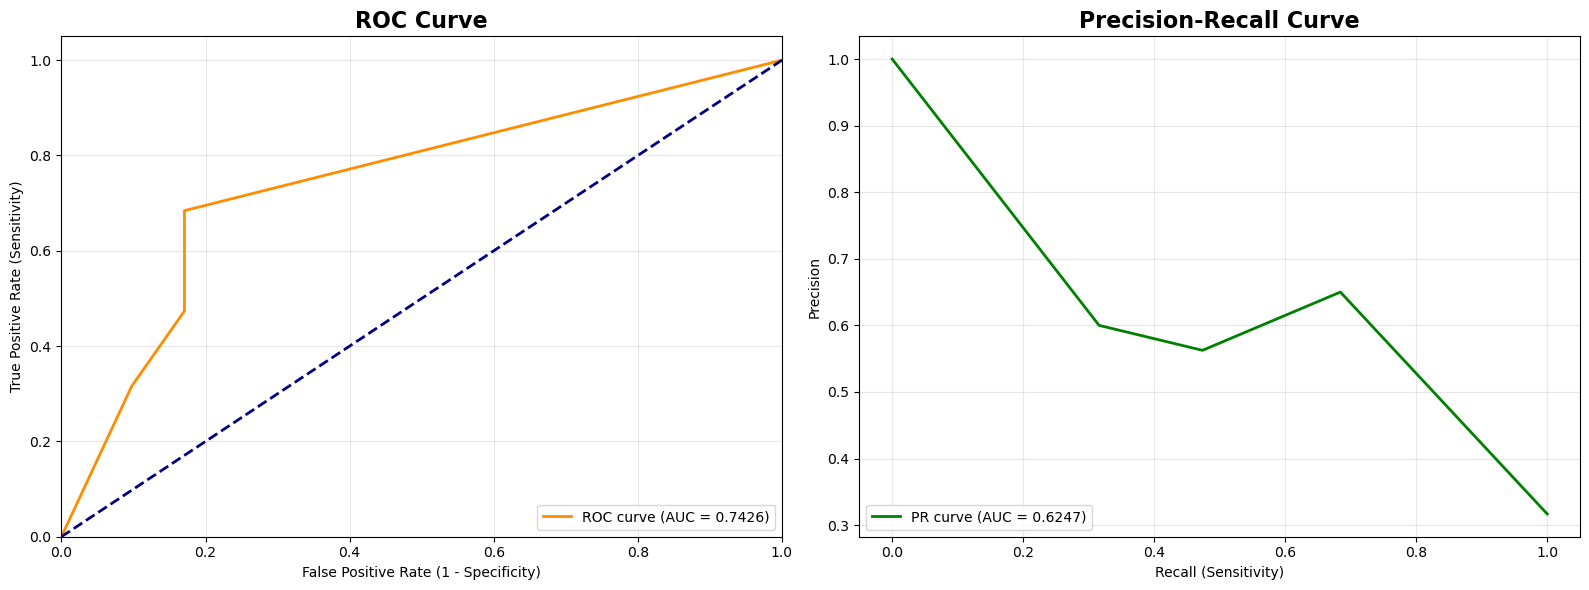

ROC AUC 점수: 0.7426
PR AUC 점수 : 0.6247


In [72]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc

# 모델이 예측한 '사망(1)'일 확률을 구하기
# (0일 확률, 1일 확률 중 두 번째 값만 가져옵니다)
y_pred_proba = final_model.predict_proba(test_input)[:, 1]

# 그래프 생성
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- [왼쪽] ROC Curve ---
fpr, tpr, thresholds = roc_curve(test_target, y_pred_proba)
roc_auc = roc_auc_score(test_target, y_pred_proba)

ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 랜덤 모델(기준선)
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate (1 - Specificity)')
ax[0].set_ylabel('True Positive Rate (Sensitivity)')
ax[0].set_title('ROC Curve', fontsize=16, fontweight='bold')
ax[0].legend(loc="lower right")
ax[0].grid(True, alpha=0.3)

# --- [오른쪽] Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(test_target, y_pred_proba)
pr_auc = auc(recall, precision)

ax[1].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
ax[1].set_xlabel('Recall (Sensitivity)')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve', fontsize=16, fontweight='bold')
ax[1].legend(loc="lower left")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC AUC 점수: {roc_auc:.4f}")
print(f"PR AUC 점수 : {pr_auc:.4f}")

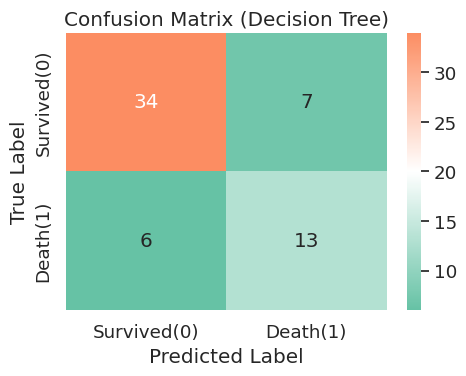

In [73]:
from sklearn.metrics import confusion_matrix

# 예측값 생성 (튜닝된 결정 트리 모델 사용)
y_pred = dt.predict(test_input)

# 혼동 행렬 계산
cm = confusion_matrix(test_target, y_pred)

# 시각화
plt.figure(figsize=(5, 4))
sns.set(font_scale=1.2)

# annot=True: 숫자 표시, fmt='d': 정수형(10진수) 표시
sns.heatmap(cm, annot=True, fmt='d', cmap=set2_cmap,
            xticklabels=['Survived(0)', 'Death(1)'],  # X축 라벨
            yticklabels=['Survived(0)', 'Death(1)'])  # Y축 라벨

plt.xlabel('Predicted Label') # 예측값
plt.ylabel('True Label')      # 실제값
plt.title('Confusion Matrix (Decision Tree)') # 제목

plt.tight_layout()
plt.show()